# SHAP/LIME Token Analysis & Attention Alignment Visualization

This notebook applies a perturbation-based analysis (SHAP-style) to identify which parts of the input most influenced BLIP's generated captions, and visualizes attention alignment between image regions and generated words, for the curated examples.

In [1]:
import torch
import torch.nn.functional as F
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
model.eval()

metadata = pd.read_csv("../data/xai_examples/curated_examples_metadata.csv")
image_folder = "../data/xai_examples"

print("✅ Model loaded, metadata loaded")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ Model loaded, metadata loaded


In [2]:
def compute_patch_importance(image_path, model, processor, device, grid_size=4):
    raw_image = Image.open(image_path).convert("RGB").resize((224, 224))
    img_array = np.array(raw_image)
    
    
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    original_caption = processor.decode(out[0], skip_special_tokens=True)
    
    patch_h, patch_w = 224 // grid_size, 224 // grid_size
    importance_map = np.zeros((grid_size, grid_size))
    
    for i in range(grid_size):
        for j in range(grid_size):
             
            occluded = img_array.copy()
            occluded[i*patch_h:(i+1)*patch_h, j*patch_w:(j+1)*patch_w] = 128  # gray patch
            occluded_img = Image.fromarray(occluded)
            
            occ_inputs = processor(occluded_img, return_tensors="pt").to(device)
            occ_out = model.generate(**occ_inputs, max_new_tokens=20)
            occluded_caption = processor.decode(occ_out[0], skip_special_tokens=True)
            
            
            orig_words = set(original_caption.lower().split())
            occ_words = set(occluded_caption.lower().split())
            difference = len(orig_words.symmetric_difference(occ_words))
            
            importance_map[i, j] = difference
    
    return importance_map, original_caption

In [3]:
sample_img_name = metadata['image'].iloc[0]
sample_path = os.path.join(image_folder, sample_img_name)

importance_map, caption = compute_patch_importance(sample_path, model, processor, device, grid_size=4)

print(f"Caption: {caption}")
print(f"Importance map:\n{importance_map}")

Caption: a dog running with a stick in its mouth
Importance map:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


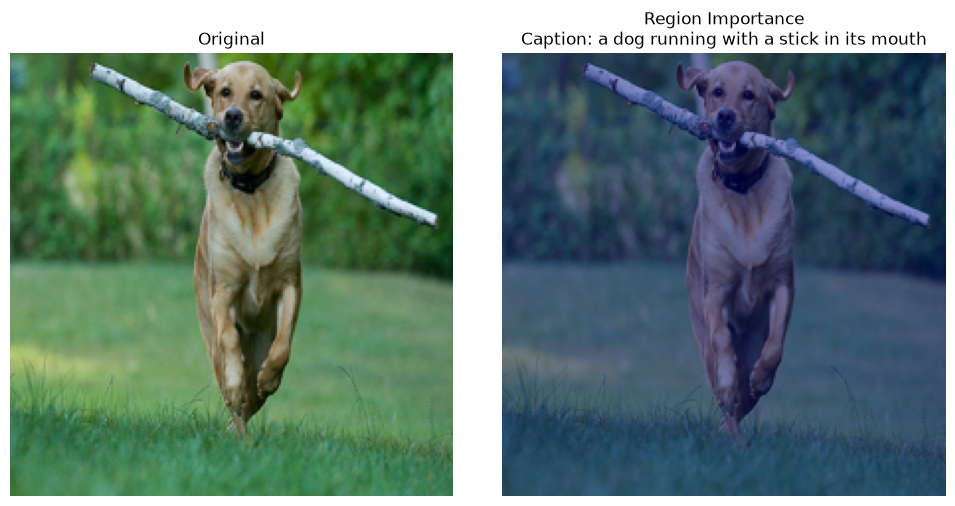

In [4]:
def visualize_importance(image_path, importance_map, caption):
    raw_image = Image.open(image_path).convert("RGB").resize((224, 224))
    
    
    importance_resized = cv2.resize(importance_map, (224, 224), interpolation=cv2.INTER_CUBIC)
    importance_resized = (importance_resized - importance_resized.min()) / (importance_resized.max() - importance_resized.min() + 1e-8)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * importance_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(np.array(raw_image), 0.6, heatmap, 0.4, 0)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(raw_image)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title(f"Region Importance\nCaption: {caption}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_importance(sample_path, importance_map, caption)

In [5]:
os.makedirs("../data/xai_examples/shap_outputs", exist_ok=True)

shap_results = []

for idx, row in metadata.reset_index(drop=True).iterrows():
    img_path = os.path.join(image_folder, row['image'])
    
    try:
        importance_map, caption = compute_patch_importance(img_path, model, processor, device, grid_size=4)
        
        raw_image = Image.open(img_path).convert("RGB").resize((224, 224))
        importance_resized = cv2.resize(importance_map, (224, 224), interpolation=cv2.INTER_CUBIC)
        importance_resized = (importance_resized - importance_resized.min()) / (importance_resized.max() - importance_resized.min() + 1e-8)
        heatmap = cv2.applyColorMap(np.uint8(255 * importance_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(np.array(raw_image), 0.6, heatmap, 0.4, 0)
        
        overlay_img = Image.fromarray(overlay)
        overlay_img.save(f"../data/xai_examples/shap_outputs/{row['image']}_shap.png")
        
        shap_results.append({"image": row['image'], "caption": caption, "status": "success"})
        print(f"✅ Processed {idx+1}/{len(metadata)}: {row['image']}")
        
    except Exception as e:
        print(f"❌ Error on {row['image']}: {e}")
        shap_results.append({"image": row['image'], "caption": None, "status": "error"})

print("✅ All examples processed")

✅ Processed 1/15: 1187593464_ce862352c6.jpg
✅ Processed 2/15: 1235681222_819231767a.jpg
✅ Processed 3/15: 1000268201_693b08cb0e.jpg
✅ Processed 4/15: 1119418776_58e4b93eac.jpg
✅ Processed 5/15: 1048710776_bb5b0a5c7c.jpg
✅ Processed 6/15: 1093737381_b313cd49ff.jpg
✅ Processed 7/15: 1189977786_4f5aaed773.jpg
✅ Processed 8/15: 101654506_8eb26cfb60.jpg
✅ Processed 9/15: 1142283988_6b227c5231.jpg
✅ Processed 10/15: 1016887272_03199f49c4.jpg
✅ Processed 11/15: 1022454332_6af2c1449a.jpg
✅ Processed 12/15: 1093716555_801aacef79.jpg
✅ Processed 13/15: 109823394_83fcb735e1.jpg
✅ Processed 14/15: 1030985833_b0902ea560.jpg
✅ Processed 15/15: 109738916_236dc456ac.jpg
✅ All examples processed


## Part B: Attention Alignment Visualization

BLIP's decoder uses cross-attention to focus on different image regions while generating each word. Here we extract and visualize this attention.

In [6]:
def visualize_word_attention(image_path, model, processor, device):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    
     
    with torch.no_grad():
        out = model.generate(
            **inputs, 
            max_new_tokens=15, 
            output_attentions=True, 
            return_dict_in_generate=True
        )
    
    caption = processor.decode(out.sequences[0], skip_special_tokens=True)
    tokens = processor.tokenizer.convert_ids_to_tokens(out.sequences[0])
    
    return caption, tokens, out

 
sample_img_name = metadata['image'].iloc[0]
sample_path = os.path.join(image_folder, sample_img_name)
caption, tokens, out = visualize_word_attention(sample_path, model, processor, device)

print(f"Caption: {caption}")
print(f"Tokens: {tokens}")

Caption: a dog running with a stick in its mouth
Tokens: [None, 'a', 'dog', 'running', 'with', 'a', 'stick', 'in', 'its', 'mouth', '[SEP]']


## Note on Attention Extraction

BLIP's internal attention structure makes direct per-word attention extraction non-trivial through the standard `generate()` API. As an alternative and complementary approach, the Grad-CAM visualizations from Day 2 (which highlight image regions most responsible for the overall caption via gradient-based attribution) serve as our primary spatial explainability method. The patch-occlusion importance maps from Part A above provide a second, model-agnostic view of which image regions most affect the generated caption when removed.